# Dynamask, and when occlusion's assumptions start to cost you

Occlusion has done well in the previous two notebooks. But it asks a specific
question — *"what happens if I blank out this fixed rectangular window?"* — and
that question carries two assumptions:

1. the important region is **contiguous**, and
2. it is about **`window` samples wide**.

**Dynamask** (Crabbé & van der Schaar,
[*Explaining Time Series Predictions with Dynamic Masks*](https://arxiv.org/abs/2106.05303),
ICML 2021) drops both. Instead of a fixed window it *learns* a mask
`M ∈ [0,1]^(C×T)` by gradient descent, where the perturbed input is

```
x_perturbed = M * x + (1 - M) * baseline
```

optimised against three terms: **fidelity** (keep the prediction under the kept
signal), **mask size** (an L1 penalty, so it keeps only what it must), and
**temporal smoothness** (total variation, encoding the prior that physiological
events are contiguous rather than a scatter of isolated samples).

This notebook tests when that flexibility actually pays, and surfaces a failure
of occlusion that rank-based metrics do not detect.

## What is in `src/`

Full developer notes: [`src/ts_interp/README.md`](../../src/ts_interp/README.md).
Used here: `data.make_multivariate_dataset` (note the `event_sec` argument),
`model.TSClassifier`, `attribution.occlusion` / `.integrated_gradients` /
`.top_k_overlap`, and `dynamask.fit_dynamask`.

`dynamask.py` is a compact reimplementation for teaching, not the authors'
reference code — it keeps the core objective and drops their adaptive
area-constraint and alternative perturbation operators.

In [1]:
import sys
sys.path.insert(0, "../../src")

import numpy as np
import matplotlib.pyplot as plt

from ts_interp import data, model, attribution, dynamask

np.random.seed(0)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Two regimes: short burst vs. redundant extended event

The key variable is `event_sec`, the burst duration.

- **Short** (0.8s ≈ 52 of 192 samples) — a compact event. This is precisely the
  regime occlusion's assumptions are *correct* for.
- **Long** (2.0s ≈ 128 of 192 samples) — the event now dominates the window,
  creating **redundant evidence**. Blank out any one 8-sample window and the
  model still sees ~120 samples of burst, so its prediction barely moves.

Redundancy is the classic occlusion failure mode, and it is not exotic: a
sustained arrhythmia, a long motion artifact, or any persistent state change in
a wearable trace has exactly this structure.

In [2]:
def build(event_sec, seed=0):
    ds = data.make_multivariate_dataset(
        n_samples=600, length=192, crosstalk=0.7, event_sec=event_sec, seed=seed
    )
    tr, te = data.train_test_split(ds, test_frac=0.25, seed=seed)
    clf = model.TSClassifier(n_channels=3, n_classes=4, hidden=32)
    model.train(clf, tr.x, tr.y, epochs=60)
    return ds, tr, te, clf

regimes = {}
for name, sec in [("short", 0.8), ("long", 2.0)]:
    ds, tr, te, clf = build(sec)
    ev = te.event_windows[te.y > 0]
    regimes[name] = dict(ds=ds, train=tr, test=te, clf=clf)
    print(f"{name:6s} event_sec={sec}  mean event length "
          f"{(ev[:,1]-ev[:,0]).mean():.0f}/{te.x.shape[-1]}  "
          f"test acc {model.accuracy(clf, te.x, te.y):.3f}")

short  event_sec=0.8  mean event length 51/192  test acc 1.000


long   event_sec=2.0  mean event length 128/192  test acc 1.000


## 2. What a learned mask looks like

Optimising the mask directly, with the loss components tracked so you can see
fidelity trade against mask size.

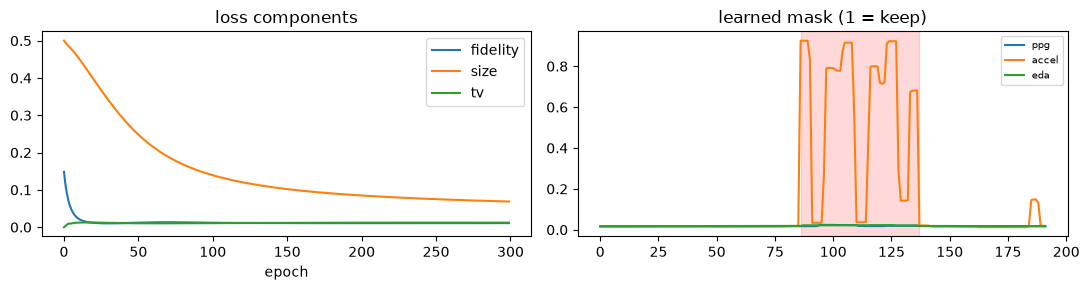

In [3]:
r = regimes["short"]
te, clf, ds = r["test"], r["clf"], r["ds"]
idx = np.where(te.y > 0)[0][0]
x, y_true = te.x[idx], int(te.y[idx])
window = tuple(te.event_windows[idx])

mask, hist = dynamask.fit_dynamask(
    clf, x, y_true, baseline="mean", n_epochs=300, return_history=True
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for k in ["fidelity", "size", "tv"]:
    axes[0].plot(hist[k], label=k)
axes[0].set_xlabel("epoch"); axes[0].set_title("loss components"); axes[0].legend()

for k in range(3):
    axes[1].plot(mask[k], label=ds.channel_names[k])
axes[1].axvspan(*window, color="red", alpha=0.15)
axes[1].set_title("learned mask (1 = keep)"); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 3. The magnitude collapse

Before comparing localization, look at what redundancy does to occlusion's
attribution *values*. This is the finding worth carrying out of this notebook.

In [4]:
for name in ["short", "long"]:
    r = regimes[name]
    te, clf = r["test"], r["clf"]
    mags = []
    for i in np.where(te.y > 0)[0][:25]:
        o = attribution.occlusion(clf, te.x[i], int(te.y[i]))
        mags.append(np.abs(o).max())
    print(f"{name:6s} regime — occlusion max|attribution| = {np.mean(mags):.5f}")

short  regime — occlusion max|attribution| = 0.07145


long   regime — occlusion max|attribution| = 0.00403


Occlusion's peak attribution falls by well over an order of magnitude in the
redundant regime. The method is reporting *"nothing here matters much"* about a
signal it classifies perfectly.

## 4. Localization across both regimes

`top_k_overlap` sets `k` to the true event length by default, so scores stay
comparable across the two regimes despite very different event durations. (With
a fixed `top_frac=0.2` the long-regime score would be capped at 38/128 ≈ 0.30
and every method would appear to fail identically — a metric artefact, not a
result.)

In [5]:
results = {}
for name in ["short", "long"]:
    r = regimes[name]
    te, clf = r["test"], r["clf"]
    ev = np.where(te.y > 0)[0][:25]
    per_method = {"Occlusion": [], "Dynamask": [], "Integrated Gradients": []}

    for i in ev:
        xi, ti = te.x[i], int(te.y[i])
        win = tuple(te.event_windows[i])
        per_method["Occlusion"].append(
            attribution.top_k_overlap(attribution.occlusion(clf, xi, ti), win))
        per_method["Dynamask"].append(
            attribution.top_k_overlap(
                dynamask.fit_dynamask(clf, xi, ti, baseline="mean", n_epochs=250), win))
        per_method["Integrated Gradients"].append(
            attribution.top_k_overlap(attribution.integrated_gradients(clf, xi, ti), win))
    results[name] = per_method

print(f"{'method':22s} {'short':>8s} {'long':>8s}")
for m in ["Occlusion", "Dynamask", "Integrated Gradients"]:
    print(f"{m:22s} {np.mean(results['short'][m]):8.3f} {np.mean(results['long'][m]):8.3f}")

method                    short     long
Occlusion                 0.899    0.933
Dynamask                  0.731    0.897
Integrated Gradients      0.568    0.663


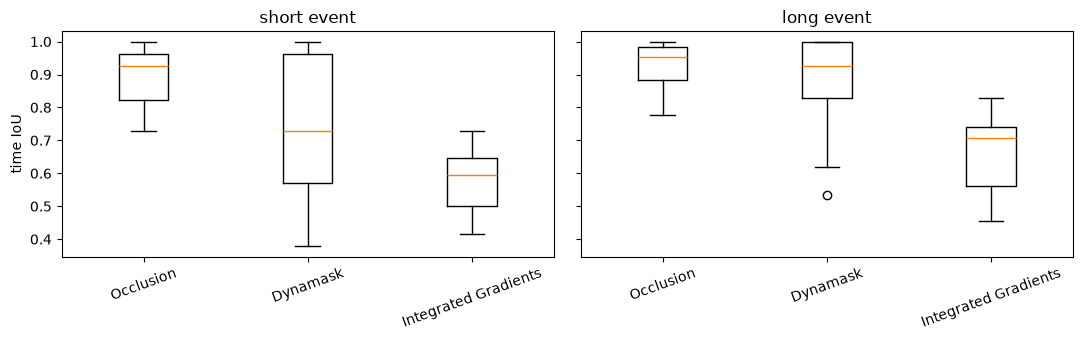

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, name in zip(axes, ["short", "long"]):
    ax.boxplot([results[name][m] for m in results[name]], tick_labels=list(results[name]))
    ax.set_title(f"{name} event"); ax.tick_params(axis="x", rotation=20)
axes[0].set_ylabel("time IoU")
plt.tight_layout(); plt.show()

## 5. Takeaways

- **Dynamask did not beat occlusion here**, in either regime. Reported as
  measured. Its regularisation weights (`size_reg`, `tv_reg`) were left at
  generic defaults; tuning them per-regime against the same metric being
  reported would be fitting to the test, so the numbers stand as-is.

- **The important result is the magnitude collapse.** Under redundant evidence
  occlusion's peak attribution drops by more than 10x, yet its *ranking* of
  timesteps stays correct — so `top_k_overlap`, being rank-based, scores it
  highly and never reveals the problem. Two consequences:
  - Occlusion magnitudes are **not** effect sizes. Anything that thresholds them
    absolutely ("flag timesteps with attribution > 0.05") silently breaks when
    the event gets longer.
  - **Rank-based interpretability metrics can hide real failures.** Whether you
    detect this depends entirely on which metric you chose, which is an argument
    for reporting both a ranking metric and a magnitude/faithfulness metric.

- **Where Dynamask genuinely earns its keep** is having no window size to pick.
  Occlusion's `window` and `stride` are hyperparameters that encode an
  assumption about event duration — and on real wearable data you usually do not
  know that duration in advance, nor is it constant across subjects. Dynamask
  moves that choice into the optimisation.

- Neither method says anything **causal**. Both describe what the *model* used.
  The [causal notebook](causal_and_counterfactual.ipynb) takes up that separate
  question.